In [76]:
from casadi import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import pickle
import lightning as L
from sklearn.preprocessing import MinMaxScaler

# Model definition

In [77]:
# Define the Ruan model from (Ruan et al., 2017), (Abuin et al., 2020)

# Parameters from (Abuin et al., 2020), identified from 10 in-silico adults
# in order: endogenous glucose production, glucose effectiveness, insulin sensitivity, carbohidrate factor, time-to-maximum effective insulin concentration, time-of-maximum appearance rate of glucose in gut)
PARAMETERS = [
    [1.327, 0.0034, 44.223, 2.308, 56.001, 21.840]
]
PATIENT = 0

theta_0 = PARAMETERS[PATIENT][0]
theta_1 = PARAMETERS[PATIENT][1]
theta_2 = PARAMETERS[PATIENT][2]
theta_3 = PARAMETERS[PATIENT][3]
theta_4 = PARAMETERS[PATIENT][4]
theta_5 = PARAMETERS[PATIENT][5]

A = DM([
    [ -theta_1  , -theta_2      , 0         , theta_3   , 0],
    [ 0         , -1/theta_4    , 1/theta_4 , 0         , 0],
    [ 0         , 0             , -1/theta_4, 0         , 0],
    [ 0         , 0             , 0         , -1/theta_5, 1/theta_5],
    [ 0         , 0             , 0         , 0         , -1/theta_5],    
    ])

# input matrix of u(t) i.e. insulin infusion rate (both basal and boluses) [U/min]
Bu = DM([[0], [0], [1/theta_4], [0], [0]])
# input matrix of r(t) u.e. carbohydrate intake rate (CHO) [g/min]
Br = DM([[0], [0], [0], [0], [1/theta_4]])
# basal steady-state endogenous glucose production
E = DM([[theta_0], [0], [0], [0], [0]])
# input (Blood Glucose Levels)
C = DM([1, 0, 0, 0, 0])

# stack the two input vectors into a single input matrix since casadi integrators only allow for one control vector
B = horzcat(Bu, Br)

print(A)
print(B)
print(E)

print(C)


[[-0.0034, -44.223, 0, 2.308, 0], 
 [0, -0.0178568, 0.0178568, 0, 0], 
 [0, 0, -0.0178568, 0, 0], 
 [0, 0, 0, -0.0457875, 0.0457875], 
 [0, 0, 0, 0, -0.0457875]]

[[0, 0], 
 [0, 0], 
 [0.0178568, 0], 
 [0, 0], 
 [0, 0.0178568]]
[1.327, 0, 0, 0, 0]
[1, 0, 0, 0, 0]


# Input preparation

In [78]:
minute = 60 # [s], one minute = 60s
hour = 60*minute # [s] one hour = 60 minutes = 60*60 seconds
day = 24*hour  # [s] one day = 24 hours = 24*60 minutes = 24*60*60 seconds

te = 28*day # simulation end time (2 days)
dt = 1*minute # how often to save results of state trajectory (5min)
tout = np.linspace(0., te, te//dt)


with open('Data/pickle/DMMSR_dataset_OnlyBasal.pkl', 'rb') as pkl:
    df = pickle.load(pkl)
print(df)

u_seq = np.array(df["insulin_U"].astype(float))
r_seq = np.array(df["meal_g"   ].astype(float))
cgm_uva = np.array(df["cgm"   ].astype(float))
tout = np.array(df["time_min"   ].astype(int))

# helper function from time in seconds to index in the tout array
def t2idx(secs):
    return int(secs * tout.size / te)

def cho_rate(cho, secs):
    return cho/secs

'''
# TEST: no meals, no basal insulin. I should observe hypoglycaemia almost immediately (IT DOES!)
u_seq = np.zeros(shape=tout.size)
r_seq = np.zeros(shape=tout.size)

print(u_seq.shape)

# meals used for dataset collection in (Sonzogni et al., 2025)
# a meal is diluted through the period of time of the meal
r_seq[t2idx( (0*day + 7.5*hour)   ):t2idx( (0*day + 7.75*hour)   )] = cho_rate(30, 15*minute)
r_seq[t2idx( (0*day + 12*hour)   ):t2idx( (0*day + 12.25*hour)   )] = cho_rate(70, 15*minute)
r_seq[t2idx( (0*day + 20*hour)   ):t2idx( (0*day + 20.25*hour)   )] = cho_rate(80, 15*minute)

r_seq[t2idx( (1*day + 7*hour)   ):t2idx( (1*day + 7.25*hour)   )] = cho_rate(20, 15*minute)
r_seq[t2idx( (1*day + 12.5*hour)   ):t2idx( (1*day + 12.75*hour)   )] = cho_rate(50, 15*minute)
r_seq[t2idx( (1*day + 19*hour)   ):t2idx( (1*day + 19.25*hour)   )] = cho_rate(60, 15*minute)'''


       time_min      cgm  insulin_U  meal_g
0           0.0  122.564   0.020397     0.0
1           1.0  123.096   0.020397     0.0
2           2.0  123.620   0.020397     0.0
3           3.0  124.134   0.020397     0.0
4           4.0  124.638   0.020397     0.0
...         ...      ...        ...     ...
40316   40316.0  198.399   0.020397     0.0
40317   40317.0  197.559   0.020397     0.0
40318   40318.0  196.769   0.020397     0.0
40319   40319.0  196.029   0.020397     0.0
40320   40320.0  195.338   0.020397     0.0

[40321 rows x 4 columns]


'\n# TEST: no meals, no basal insulin. I should observe hypoglycaemia almost immediately (IT DOES!)\nu_seq = np.zeros(shape=tout.size)\nr_seq = np.zeros(shape=tout.size)\n\nprint(u_seq.shape)\n\n# meals used for dataset collection in (Sonzogni et al., 2025)\n# a meal is diluted through the period of time of the meal\nr_seq[t2idx( (0*day + 7.5*hour)   ):t2idx( (0*day + 7.75*hour)   )] = cho_rate(30, 15*minute)\nr_seq[t2idx( (0*day + 12*hour)   ):t2idx( (0*day + 12.25*hour)   )] = cho_rate(70, 15*minute)\nr_seq[t2idx( (0*day + 20*hour)   ):t2idx( (0*day + 20.25*hour)   )] = cho_rate(80, 15*minute)\n\nr_seq[t2idx( (1*day + 7*hour)   ):t2idx( (1*day + 7.25*hour)   )] = cho_rate(20, 15*minute)\nr_seq[t2idx( (1*day + 12.5*hour)   ):t2idx( (1*day + 12.75*hour)   )] = cho_rate(50, 15*minute)\nr_seq[t2idx( (1*day + 19*hour)   ):t2idx( (1*day + 19.25*hour)   )] = cho_rate(60, 15*minute)'

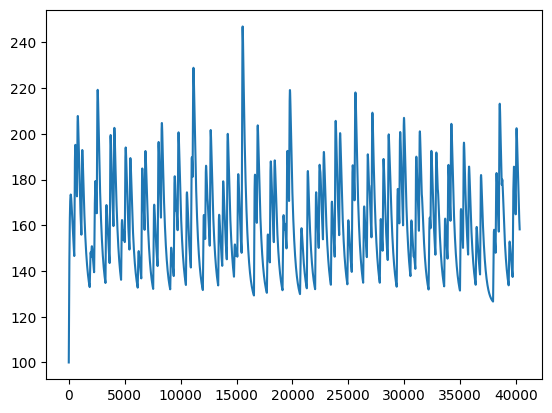

In [79]:
# continuous time integration with pre-programmed meals and insulin
# slicer = slice(0,-1)

x = MX.sym('x', 5)
U = MX.sym('u', 2)

ode = {'x':x, 'u': U, 'ode': A@x + B@U + E}
F = integrator('F','rk',ode, 0, tout ,{})

# integration only allows for one control vector U, so the u, r have to be stacked
U_seq = horzcat(u_seq, r_seq).T

# integrate
res = F(x0=[100,0,0,0,0], u=U_seq)

cgm_ruan = np.array(res['xf'][0,:].T)
fig, ax = plt.subplots()
ax.plot(tout, cgm_ruan) # np.array(df["cgm"])[slicer]

# Dataset preparation

LSTM layers require sequences as inputs.
Divide the data into input (insulin by controller, meals) and output sequences. Use some days for training, some for validation, some for testing.


In [80]:
import torch
from torch import nn
from torch.nn.utils.rnn import pack_sequence
from torch.utils.data import Dataset, DataLoader


# device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float32)
torch.set_default_device("cuda")
torch.get_default_device()
torch.set_float32_matmul_precision('high')


batch_size = 32

# Two inputs: u,r
# Create packed sequences of multiple u,r
# Each sequence is obtained by sampling the dataset for 3hours. No overlap between sequences
# https://docs.pytorch.org/docs/2.12/generated/torch.nn.utils.rnn.pack_sequence.html#torch.nn.utils.rnn.pack_sequence
# https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html

class SequenceDataset(Dataset):
    def __init__(self, insulin, meals, cgm_ruan, cgm_uva, seq_length):
        assert max(insulin.shape) == max(meals.shape) == max(cgm_ruan.shape) == max(cgm_uva.shape)
        
        data = torch.cat((insulin, meals), dim=0)
        self.len = max(data.shape)-seq_length-1
        
        # split into sequencies of length seq_length and with a stride of 1
        self.y = (cgm_uva - cgm_ruan)[:,:self.len].T
        
        x = []
        for i in range(self.len):
            _x = data[:,i:(i+seq_length)].T
            x.append(_x)
        
        x = torch.stack(x, dim=0)

        # min max scaling to bring in the -1, 1 range for tanh in lstm layer
        x_std = x-torch.min(x) / (torch.max(x) - torch.min(x))
        self.x = x_std * (1 - -1) + -1
                
    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# downsample to every x minutes instead of every 1 minute
downsample_min = 5

# and cast to pytorch tensors
insulin_t = torch.tensor(u_seq[::downsample_min], dtype=torch.float32).reshape(1, -1)
meals_t = torch.tensor(r_seq[::downsample_min], dtype=torch.float32).reshape(1, -1)
cgm_ruan_t = torch.tensor(cgm_ruan[::downsample_min], dtype=torch.float32).reshape(1, -1)
cgm_uva_t = torch.tensor(cgm_uva[::downsample_min], dtype=torch.float32).reshape(1, -1)

# Associate each sequence with its respective output
train_dataset = SequenceDataset(insulin_t, meals_t, cgm_ruan_t, cgm_uva_t, 20)

# Dataset loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=False)

x, y = next(iter(train_loader))
print(x.shape, x)
print(y.shape, y)

# test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
#                                           batch_size=batch_size, 
#                                           shuffle=False)

torch.Size([32, 20, 2]) tensor([[[-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         ...,
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000]],

        [[-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         ...,
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000]],

        [[-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         ...,
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000]],

        ...,

        [[-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         ...,
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000]],

        [[-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         ...,
         [-0.9592, -1.0000],
         [-0.9592, -1.0000],
         [-0.9592, -1.0000]],

        [[-0

# NN structure

The NN is made of two LSTM layers and two FC layers

In [ ]:
# Lightning Module for LSTM Model
# https://lightning.ai/lightning-ai/templates/time-series-forecasting-with-pytorch-lightning?section=featured
class NN(L.LightningModule):
    def __init__(self, input_dim=2, hidden_dim=150, output_dim=1):
        super().__init__()
        # torch.manual_seed(2)

        # multiple LSTM layers
        # The first layer has two inputs (insulin, meal) and some hidden states

        # TODO: dropout, L2 regularization?
        self.lstm = nn.LSTM(input_dim, hidden_dim, dropout=0.2, batch_first=True)

        # one readout layer
        # the output is the correction to a single sampling time, so dimension 1
        self.fc1 = torch.nn.Linear(hidden_dim, hidden_dim)    
        self.activation = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        res, (h_n, c_n) = self.lstm(x.squeeze())
        res = self.fc1(h_n)
        res = self.activation(res)
        res = self.fc2(res)
        # TODO: detach? https://github.com/ritchieng/deep-learning-wizard/blob/master/docs/deep_learning/practical_pytorch/pytorch_lstm_neuralnetwork.md
        return res

        # _, (hidden, _) = self.lstm(x)
        # return self.fc(hidden[-1])

    def training_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs.unsqueeze(-1)).reshape((-1, 1))

        loss = torch.nn.functional.mse_loss(outputs, targets)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

# hidden states size is a hyperparameter. The real dynamics of the Ruan model has five state components
# using PyTorch lightning

model = NN(input_dim=2, hidden_dim=20)
trainer = L.Trainer(max_epochs=1000)
trainer.fit(model, train_loader)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type   | Params | Mode  | FLOPs
------------------------------------------------------
0 | lstm       | LSTM   | 1.9 K  | train | 0    
1 | fc

Epoch 24:  48%|████▊     | 120/252 [00:00<00:00, 202.07it/s, v_num=33, train_loss=2.4e+3] 